In [ ]:
# Data Exploration and Cleaning


import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


df = pd.read_csv('/content/NIFTY50_all.csv')

df.dropna(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')


In [ ]:
# Check for any missing values in each column
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Remove rows with any missing values to keep the dataset clean
df.dropna(inplace=True)

# Convert the 'Date' column from a string to a datetime object
df['Date'] = pd.to_datetime(df['Date'])

# Sort the dataset by date to ensure it's in chronological order
df = df.sort_values(by='Date')

print("\n--- Data Cleaned and Sorted ---")
df.info()


--- Missing Values ---
Date                  0
Symbol                0
Series                0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
%Deliverble           0
dtype: int64

--- Data Cleaned and Sorted ---
<class 'pandas.core.frame.DataFrame'>
Index: 120344 entries, 866 to 235191
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                120344 non-null  datetime64[ns]
 1   Symbol              120344 non-null  object        
 2   Series              120344 non-null  object        
 3   Prev Close          120344 non-null  float64       
 4   Open                120344 non-null  float64       
 5   High                120344 non-null  float64       
 6   L

In [ ]:
#Preprocessing and Baseline LSTM Model


from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Filter the DataFrame to get data for a single stock, e.g., 'TCS'
df_stock = df[df['Symbol'] == 'TCS'].copy()

# We will use the 'Close' price for prediction
data = df_stock.filter(['Close'])
dataset = data.values # Convert to a numpy array

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

In [ ]:
# Use the first 80% of the data for training
training_data_len = int(np.ceil(len(dataset) * 0.8))

# Create the training dataset
train_data = scaled_data[0:int(training_data_len), :]

# Split the data into x_train and y_train datasets
x_train = []
y_train = []

# This loop is where x_train is created
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0]) # 60 previous prices
    y_train.append(train_data[i, 0])     # The 61st price

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data for the LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print("x_train has been created successfully!")

x_train has been created successfully!


In [ ]:
#  Full Model Training and Evaluation


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
import time
import numpy as np

print("\n--- Starting Real-Time Simulation (for 50 steps) ---")


test_data = scaled_data[training_data_len - 60:, :]
y_test = dataset[training_data_len:, :]
current_sequence = test_data[0:60, 0]


for i in range(50):
    # Reshape the current sequence for the model
    sequence_for_prediction = np.reshape(current_sequence, (1, 60, 1))

    # Get the model's predicted scaled price
    predicted_scaled_price = model.predict(sequence_for_prediction, verbose=0) # Added verbose=0 to clean the output

    # Un-scale the prediction to get the actual price
    predicted_price = scaler.inverse_transform(predicted_scaled_price)

    # Get the actual price for this day from our test set
    actual_price = y_test[i]

    print(f"Day {i+1} -> Prediction: ₹{predicted_price[0][0]:.2f} | Actual Price: ₹{actual_price[0]:.2f}")

    # Update the sequence for the next prediction
    new_scaled_price = test_data[60 + i, 0]
    current_sequence = np.append(current_sequence, new_scaled_price)
    current_sequence = current_sequence[1:]

    # Pause to make the simulation look real-time
    time.sleep(1)

print("\n--- Simulation Finished ---")


--- Starting Real-Time Simulation (for 50 steps) ---
Day 1 -> Prediction: ₹1036.27 | Actual Price: ₹2172.55
Day 2 -> Prediction: ₹1035.99 | Actual Price: ₹2135.80
Day 3 -> Prediction: ₹1035.49 | Actual Price: ₹2128.75
Day 4 -> Prediction: ₹1034.84 | Actual Price: ₹2092.35
Day 5 -> Prediction: ₹1033.84 | Actual Price: ₹2095.40
Day 6 -> Prediction: ₹1032.78 | Actual Price: ₹2108.75
Day 7 -> Prediction: ₹1031.93 | Actual Price: ₹2095.45
Day 8 -> Prediction: ₹1031.15 | Actual Price: ₹2143.95
Day 9 -> Prediction: ₹1030.92 | Actual Price: ₹2109.75
Day 10 -> Prediction: ₹1030.68 | Actual Price: ₹2081.75
Day 11 -> Prediction: ₹1030.18 | Actual Price: ₹2054.05
Day 12 -> Prediction: ₹1029.35 | Actual Price: ₹2048.00
Day 13 -> Prediction: ₹1028.38 | Actual Price: ₹2055.15
Day 14 -> Prediction: ₹1027.52 | Actual Price: ₹2073.75
Day 15 -> Prediction: ₹1026.97 | Actual Price: ₹2107.55
Day 16 -> Prediction: ₹1026.96 | Actual Price: ₹2146.30
Day 17 -> Prediction: ₹1027.58 | Actual Price: ₹2196.55
Day

In [ ]:

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print("x_train has been reshaped successfully!")
print("The new shape of x_train is:", x_train.shape)

x_train has been reshaped successfully!
The new shape of x_train is: (1905, 60, 1)


In [ ]:
!pip install kafka-python


In [ ]:
# Integration with Kafka (Conceptual)


# producer.py - (Conceptual Code)
from kafka import KafkaProducer
import json
import time

producer = KafkaProducer(bootstrap_servers='localhost:9092',
                         value_serializer=lambda v: json.dumps(v).encode('utf-8'))


for index, row in df_stock.head(50).iterrows():
    message = row.to_dict()
    message['Date'] = message['Date'].strftime('%Y-%m-%d')
    producer.send('stock-topic', value=message)
    print(f"Sent: {message['Symbol']} price {message['Close']}")
    time.sleep(1)

Sent: TCS price 1175.4
Sent: TCS price 1167.75
Sent: TCS price 1152.1
Sent: TCS price 1164.35
Sent: TCS price 1179.3
Sent: TCS price 1181.4
Sent: TCS price 1186.35
Sent: TCS price 1189.2
Sent: TCS price 1175.3
Sent: TCS price 1191.05
Sent: TCS price 1184.25
Sent: TCS price 1151.15
Sent: TCS price 1109.2
Sent: TCS price 1069.3
Sent: TCS price 1106.75
Sent: TCS price 1083.5
Sent: TCS price 1097.0
Sent: TCS price 1137.75
Sent: TCS price 1150.6
Sent: TCS price 1154.0
Sent: TCS price 1169.85
Sent: TCS price 1184.2
Sent: TCS price 1191.9
Sent: TCS price 1185.7
Sent: TCS price 1179.45
Sent: TCS price 1182.8
Sent: TCS price 1195.9
Sent: TCS price 1171.65
Sent: TCS price 1156.65
Sent: TCS price 1145.35
Sent: TCS price 1149.05
Sent: TCS price 1123.7
Sent: TCS price 1146.05
Sent: TCS price 1125.05
Sent: TCS price 1140.05
Sent: TCS price 1132.45
Sent: TCS price 1122.55
Sent: TCS price 1133.4
Sent: TCS price 1139.9
Sent: TCS price 1144.65
Sent: TCS price 1147.15
Sent: TCS price 1129.55
Sent: TCS pr

In [ ]:
from kafka import KafkaConsumer
import json
import numpy as np



print("--- Preparing for Live Predictions ---")


last_60_days = list(scaled_data[training_data_len - 60:])


consumer = KafkaConsumer(
    'stock-topic',
    bootstrap_servers='localhost:9092',
    auto_offset_reset='earliest',
    group_id='stock-prediction-group',
    value_deserializer=lambda m: json.loads(m.decode('utf-8'))
)

print("Consumer is listening for live stock data...")
print("-" * 50)

for message in consumer:

    stock_data = message.value
    new_price = stock_data['Close']

    print(f"Received new price: ₹{new_price:.2f}")


    scaled_new_price = scaler.transform([[new_price]])

    last_60_days.append(scaled_new_price[0])
    last_60_days = last_60_days[1:]

    sequence_for_prediction = np.array([last_60_days])

    predicted_scaled_price = model.predict(sequence_for_prediction, verbose=0)

    predicted_price = scaler.inverse_transform(predicted_scaled_price)

    print(f"-> PREDICTION for next day: ₹{predicted_price[0][0]:.2f}")
    print("-" * 20)

--- Preparing for Live Predictions ---
Consumer is listening for live stock data...
--------------------------------------------------
Received new price: ₹1175.40
-> PREDICTION for next day: ₹1101.07
--------------------
Received new price: ₹1167.75
-> PREDICTION for next day: ₹1074.39
--------------------
Received new price: ₹1152.10
-> PREDICTION for next day: ₹1046.64
--------------------
Received new price: ₹1164.35
-> PREDICTION for next day: ₹1021.57
--------------------
Received new price: ₹1179.30
-> PREDICTION for next day: ₹1000.60
--------------------
Received new price: ₹1181.40
-> PREDICTION for next day: ₹983.82
--------------------
Received new price: ₹1186.35
-> PREDICTION for next day: ₹970.85
--------------------
Received new price: ₹1189.20
-> PREDICTION for next day: ₹961.11
--------------------
Received new price: ₹1175.30
-> PREDICTION for next day: ₹953.86
--------------------
Received new price: ₹1191.05
-> PREDICTION for next day: ₹948.78
--------------------


KeyboardInterrupt: 

--- Generating predictions for visualization... ---
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
--- Creating the plot... ---


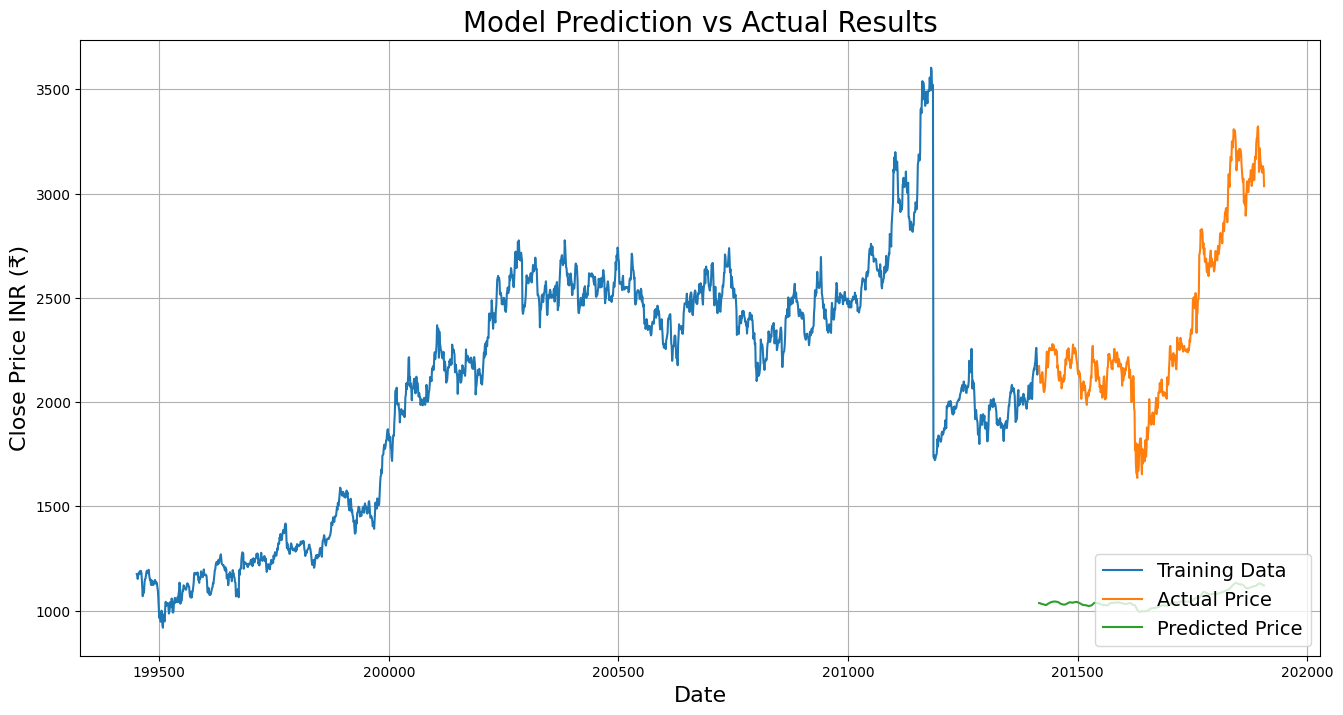

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


print("--- Generating predictions for visualization... ---")

test_data = scaled_data[training_data_len - 60:, :]
x_test = []
y_test = dataset[training_data_len:, :]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)


train = data[:training_data_len]
valid = data[training_data_len:].copy()
valid['Predictions'] = predictions


print("--- Creating the plot... ---")
plt.figure(figsize=(16, 8))
plt.title('Model Prediction vs Actual Results', fontsize=20)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Close Price INR (₹)', fontsize=16)

plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Actual Price')
plt.plot(valid['Predictions'], label='Predicted Price')

plt.legend(loc='lower right', fontsize=14)
plt.grid(True)
plt.show()
